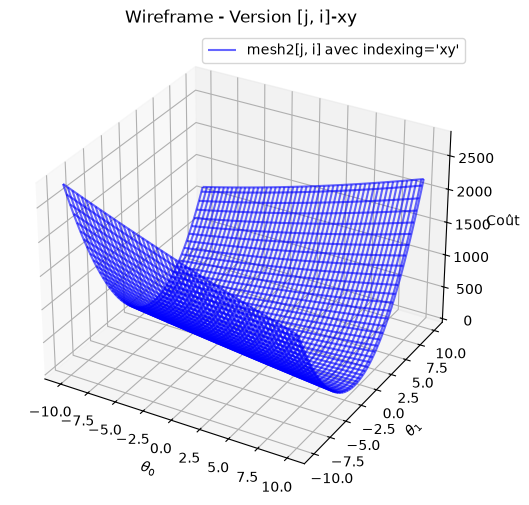

In [1]:
  
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(2020) # Pour la reproductibilité des résultats
theta_0_th = -0.5
theta_1_th = 0.75
x = np.random.uniform(1,10,100)
y = theta_0_th + (theta_1_th * x) + np.random.randn(100) ## on ajoute une petite erreur. Équivalent de standard_normal 

# 1. Données de test
theta_0s = np.linspace(-10, 10, 100)  # Longueur 40
theta_1s = np.linspace(-10, 10, 100)  # Longueur 50

# Fonction de coût factice
def cost_function(x, y, t0, t1):
    y_calc = t0 + t1 * x
    return np.sum((y_calc - y) ** 2) / (2 * len(x))

# 2. Remplissage de la matrice avec les boucles imbriquées [j, i]
# Dimension requise : (nb_theta_1, nb_theta_0) -> (50, 40)
mesh2 = np.zeros((len(theta_1s), len(theta_0s)))

for i, theta0 in enumerate(theta_0s):
    for j, theta1 in enumerate(theta_1s):
        mesh2[j, i] = cost_function(x, y, theta0, theta1)

# 3. Création du Meshgrid compatible (Mode par défaut 'xy')
XX, YY = np.meshgrid(theta_0s, theta_1s, indexing='xy')

# 4. Tracé Graphique
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

ax.plot_wireframe(
    XX,
    YY,
    mesh2,
    rstride=2,
    cstride=2,
    color="blue",
    alpha=0.6,
    label="mesh2[j, i] avec indexing='xy'"
)

ax.set_xlabel(r'$\theta_0$')
ax.set_ylabel(r'$\theta_1$')
ax.set_zlabel('Coût')
plt.title("Wireframe - Version [j, i]-xy")
plt.legend()
plt.show()

theta_0 calculé : -0.6194
theta_1 calculé : 0.7828
Coût minimal     : 0.4912


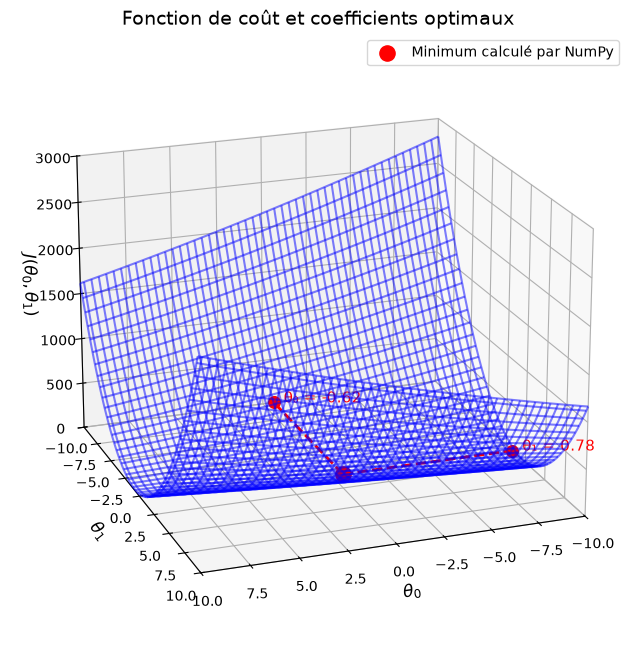

Indice i de theta_0 : 49
Indice j de theta_1 : 53
theta_0 : -0.10101010101010033
theta_1 : 0.7070707070707076
Coût minimal : 0.5157057560490922


In [9]:
import numpy as np
import matplotlib.pyplot as plt


# ---------------------------------------------------------
# 1. Création des données
# ---------------------------------------------------------

np.random.seed(2020)

theta_0_th = -0.5
theta_1_th = 0.75

x = np.random.uniform(1, 10, 100)

y = (
    theta_0_th
    + theta_1_th * x
    + np.random.randn(100)
)


# ---------------------------------------------------------
# 2. Fonction de coût
# ---------------------------------------------------------

def cost_function(x, y, theta_0, theta_1):
    y_calc = theta_0 + theta_1 * x

    cost = np.sum(
        (y_calc - y) ** 2
    ) / (2 * len(x))

    return cost


# ---------------------------------------------------------
# 3. Valeurs possibles de theta_0 et theta_1
# ---------------------------------------------------------

theta_0s = np.linspace(-10, 10, 100)
theta_1s = np.linspace(-10, 10, 100)


# ---------------------------------------------------------
# 4. Création du meshgrid
#
# Avec indexing="xy" :
#   lignes   -> theta_1
#   colonnes -> theta_0
#
# La forme obtenue est donc :
# (len(theta_1s), len(theta_0s))
# ---------------------------------------------------------

XX, YY = np.meshgrid(
    theta_0s,
    theta_1s,
    indexing="xy"
)

mesh = np.zeros(
    (len(theta_1s), len(theta_0s))
)


# ---------------------------------------------------------
# 5. Calcul de la fonction de coût
#
# j représente la ligne, donc theta_1
# i représente la colonne, donc theta_0
# ---------------------------------------------------------

for i, theta_0 in enumerate(theta_0s):
    for j, theta_1 in enumerate(theta_1s):

        mesh[j, i] = cost_function(
            x,
            y,
            theta_0,
            theta_1
        )


# ---------------------------------------------------------
# 6. Calcul des coefficients optimaux avec NumPy
# ---------------------------------------------------------

theta_0_np, theta_1_np = (
    np.polynomial.Polynomial
    .fit(x, y, deg=1)
    .convert()
    .coef
)

cost_np = cost_function(
    x,
    y,
    theta_0_np,
    theta_1_np
)

print(f"theta_0 calculé : {theta_0_np:.4f}")
print(f"theta_1 calculé : {theta_1_np:.4f}")
print(f"Coût minimal     : {cost_np:.4f}")


# ---------------------------------------------------------
# 7. Création du graphique 3D
# ---------------------------------------------------------

fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection="3d")

ax.view_init(
    elev=20,
    azim=70
)

ax.plot_wireframe(
    XX,
    YY,
    mesh,
    rstride=2,
    cstride=2,
    color="blue",
    alpha=0.5
)


# ---------------------------------------------------------
# 8. Limites utilisées pour les projections
# ---------------------------------------------------------

theta_0_min = theta_0s.min()
theta_1_min = theta_1s.min()
z_floor = 0


# ---------------------------------------------------------
# 9. Point optimal calculé par NumPy
# ---------------------------------------------------------

ax.scatter(
    theta_0_np,
    theta_1_np,
    cost_np,
    color="red",
    marker="o",
    s=120,
    depthshade=False,
    label="Minimum calculé par NumPy"
)


# ---------------------------------------------------------
# 10. Projection verticale jusqu’au plan theta_0-theta_1
# ---------------------------------------------------------

ax.plot(
    [theta_0_np, theta_0_np],
    [theta_1_np, theta_1_np],
    [cost_np, z_floor],
    color="red",
    linestyle="--",
    linewidth=2
)

# Point projeté sur le plan inférieur
ax.scatter(
    theta_0_np,
    theta_1_np,
    z_floor,
    color="red",
    marker="o",
    s=50,
    depthshade=False
)


# ---------------------------------------------------------
# 11. Projection vers l’axe theta_0
#
# theta_0 demeure fixe et theta_1 se dirige vers son minimum
# ---------------------------------------------------------

ax.plot(
    [theta_0_np, theta_0_np],
    [theta_1_np, theta_1_min],
    [z_floor, z_floor],
    color="red",
    linestyle="--",
    linewidth=2
)

ax.scatter(
    theta_0_np,
    theta_1_min,
    z_floor,
    color="red",
    s=70,
    depthshade=False
)

ax.text(
    theta_0_np,
    theta_1_min,
    z_floor,
    f"  θ₀ = {theta_0_np:.2f}",
    color="red",
    fontsize=11
)


# ---------------------------------------------------------
# 12. Projection vers l’axe theta_1
#
# theta_1 demeure fixe et theta_0 se dirige vers son minimum
# ---------------------------------------------------------

ax.plot(
    [theta_0_np, theta_0_min],
    [theta_1_np, theta_1_np],
    [z_floor, z_floor],
    color="red",
    linestyle="--",
    linewidth=2
)

ax.scatter(
    theta_0_min,
    theta_1_np,
    z_floor,
    color="red",
    s=70,
    depthshade=False
)

ax.text(
    theta_0_min,
    theta_1_np,
    z_floor,
    f"  θ₁ = {theta_1_np:.2f}",
    color="red",
    fontsize=11
)


# ---------------------------------------------------------
# 13. Configuration finale
# ---------------------------------------------------------

ax.set_xlim(theta_0s.min(), theta_0s.max())
ax.set_ylim(theta_1s.min(), theta_1s.max())
ax.set_zlim(bottom=0)

ax.set_xlabel(r"$\theta_0$", fontsize=12)
ax.set_ylabel(r"$\theta_1$", fontsize=12)
ax.set_zlabel(r"$J(\theta_0,\theta_1)$", fontsize=12)

ax.set_title(
    "Fonction de coût et coefficients optimaux",
    fontsize=14
)

ax.legend()

plt.show()


# Position du coût minimal dans mesh
j_min, i_min = np.unravel_index(
    np.argmin(mesh),
    mesh.shape
)

# Valeurs de theta correspondantes
theta_0_min = theta_0s[i_min]
theta_1_min = theta_1s[j_min]

# Valeur minimale de la fonction de coût
cost_min = mesh[j_min, i_min]

print(f"Indice i de theta_0 : {i_min}")
print(f"Indice j de theta_1 : {j_min}")

print(f"theta_0 : {theta_0_min}")
print(f"theta_1 : {theta_1_min}")
print(f"Coût minimal : {cost_min}")